# Group V — ViT-GPT2 Action-Only Captioning + BLIP/GIT Comparison

This Kaggle notebook uses:

- **COCO Train2014 images**: `/kaggle/input/datasets/torrentbrave/coco-train2014-image`
- **Action-caption CSV**: `/kaggle/input/datasets/uwellcome/coco-action-captions-training-ready`
- **Demo videos**: `/kaggle/input/datasets/uwellcome/mydemo`

Goal:

1. Fine-tune **ViT-GPT2** on `image -> action_caption`.
2. Evaluate original vs fine-tuned ViT-GPT2 against `action_caption`.
3. Compare with teammate **BLIP** and **Microsoft GIT** results.
4. Show evaluation examples **with input images**.
5. Save/cache heavy outputs so they can be reused.


In [1]:
# ============================================================
# CELL 1 — Imports, paths, GPU check, and configuration
# Zero-install notebook: do NOT pip install torch/transformers.
# ============================================================

import os, re, json, math, random, shutil, zipfile, urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    VisionEncoderDecoderModel,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

try:
    from transformers import ViTImageProcessor
except Exception:
    from transformers import ViTFeatureExtractor as ViTImageProcessor

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    x = torch.tensor([1.0, 2.0, 3.0], device="cuda")
    print("CUDA test:", x * 2)
else:
    print("WARNING: Enable GPU T4 in Kaggle settings.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# Main settings
# -------------------------
MODEL_NAME = "nlpconnect/vit-gpt2-image-captioning"

# Action captions are short.
MAX_TARGET_LENGTH = 16

# Final run settings. For a quick test, temporarily use 500 / 100.
TRAIN_SIZE = 20000
VAL_SIZE = 3000

# Improved fine-tuning settings.
# More epochs + lower LR usually improves short action-caption style.
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 2
EPOCHS = 3
LR = 1e-5
WEIGHT_DECAY = 0.01

# Cache behavior
RETRAIN_FINETUNED = True
FORCE_REGENERATE_ORIGINAL_PREDS = False
FORCE_REGENERATE_FINETUNED_PREDS = False

# Generation tuning for fine-tuned model
TUNE_GENERATION_FOR_FINETUNED = False
GEN_TUNE_LIMIT = 300

# Kaggle input paths
COCO_TRAIN2014_ROOT = Path("/kaggle/input/datasets/torrentbrave/coco-train2014-image")
ACTION_CSV_ROOT = Path("/kaggle/input/datasets/uwellcome/coco-action-captions-training-ready")
DEMO_VIDEO_ROOT = Path("/kaggle/input/datasets/uwellcome/mydemo")

# Common Kaggle alternative paths
if not COCO_TRAIN2014_ROOT.exists():
    alt = Path("/kaggle/input/coco-train2014-image")
    if alt.exists():
        COCO_TRAIN2014_ROOT = alt

if not ACTION_CSV_ROOT.exists():
    alt = Path("/kaggle/input/coco-action-captions-training-ready")
    if alt.exists():
        ACTION_CSV_ROOT = alt

if not DEMO_VIDEO_ROOT.exists():
    alt = Path("/kaggle/input/mydemo")
    if alt.exists():
        DEMO_VIDEO_ROOT = alt

LOCAL_TRAIN2014_DIR = COCO_TRAIN2014_ROOT / "train2014"

WORK_DIR = Path("/kaggle/working")
WORK_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = WORK_DIR / "saved_heavy_outputs"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_DIR = WORK_DIR / "coco_downloaded_images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DF_PATH = CACHE_DIR / "train_df_used.csv"
VAL_DF_PATH = CACHE_DIR / "val_df_used.csv"

ORIGINAL_PREDS_PATH = CACHE_DIR / "vit_gpt2_original_predictions.csv"
FINETUNED_PREDS_PATH = CACHE_DIR / "vit_gpt2_finetuned_predictions.csv"
COMPARISON_PATH = CACHE_DIR / "vit_gpt2_comparison_predictions.csv"
VIT_METRICS_PATH = CACHE_DIR / "vit_gpt2_metrics.csv"
ALL_MODELS_METRICS_PATH = CACHE_DIR / "all_models_comparison_metrics.csv"
FINETUNED_GEN_CONFIG_PATH = CACHE_DIR / "vit_gpt2_finetuned_best_generation_config.json"
QUALITATIVE_GRID_PATH = CACHE_DIR / "vit_gpt2_qualitative_examples_grid.png"

FINAL_MODEL_DIR = WORK_DIR / "final_vit_gpt2_coco_action_model"
FINAL_MODEL_ZIP = WORK_DIR / "final_vit_gpt2_coco_action_model.zip"
BACKUP_ZIP = WORK_DIR / "group_v_heavy_outputs_backup.zip"

print("DEVICE:", DEVICE)
print("COCO_TRAIN2014_ROOT:", COCO_TRAIN2014_ROOT, COCO_TRAIN2014_ROOT.exists())
print("LOCAL_TRAIN2014_DIR:", LOCAL_TRAIN2014_DIR, LOCAL_TRAIN2014_DIR.exists())
print("ACTION_CSV_ROOT:", ACTION_CSV_ROOT, ACTION_CSV_ROOT.exists())
print("DEMO_VIDEO_ROOT:", DEMO_VIDEO_ROOT, DEMO_VIDEO_ROOT.exists())
print("CACHE_DIR:", CACHE_DIR)


Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA test: tensor([2., 4., 6.], device='cuda:0')
DEVICE: cuda
COCO_TRAIN2014_ROOT: /kaggle/input/datasets/torrentbrave/coco-train2014-image True
LOCAL_TRAIN2014_DIR: /kaggle/input/datasets/torrentbrave/coco-train2014-image/train2014 True
ACTION_CSV_ROOT: /kaggle/input/datasets/uwellcome/coco-action-captions-training-ready True
DEMO_VIDEO_ROOT: /kaggle/input/datasets/uwellcome/mydemo True
CACHE_DIR: /kaggle/working/saved_heavy_outputs


In [2]:
# ============================================================
# CELL 2 — Optional restore from previous backup zip
# Attach a previous output dataset containing group_v_heavy_outputs_backup.zip.
# ============================================================

possible_backups = list(Path("/kaggle/input").rglob("group_v_heavy_outputs_backup.zip")) if Path("/kaggle/input").exists() else []

if possible_backups:
    backup = possible_backups[0]
    print("Found previous backup zip:", backup)
    with zipfile.ZipFile(backup, "r") as zf:
        zf.extractall(WORK_DIR)
    print("Restored backup into:", WORK_DIR)
else:
    print("No previous backup zip found. Starting fresh.")


No previous backup zip found. Starting fresh.


In [3]:
# ============================================================
# CELL 3 — Load action-caption CSV and create train/validation split
# ============================================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

csv_files = list(ACTION_CSV_ROOT.rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV found inside {ACTION_CSV_ROOT}")

CSV_PATH = csv_files[0]
print("Using CSV:", CSV_PATH)

raw_df = pd.read_csv(CSV_PATH)
print("CSV shape:", raw_df.shape)
print("Columns:", list(raw_df.columns))

lower_to_col = {c.lower().strip().replace(" ", "_").replace("-", "_"): c for c in raw_df.columns}

def find_col(candidates):
    for c in candidates:
        if c in lower_to_col:
            return lower_to_col[c]
    return None

image_id_col = find_col(["image_id", "id", "coco_id"])
file_name_col = find_col(["file_name", "filename", "image", "image_name"])
image_url_col = find_col(["image_url", "url"])
original_caption_col = find_col(["original_caption", "caption", "raw_caption", "coco_caption", "text"])
action_caption_col = find_col(["action_caption", "short_caption", "target_caption", "event_caption", "action"])
split_col = find_col(["split", "dataset_split"])

if action_caption_col is None:
    raise ValueError("No action_caption column found. Available columns: " + str(list(raw_df.columns)))
if original_caption_col is None:
    original_caption_col = action_caption_col

data = pd.DataFrame()

if image_id_col is not None:
    data["image_id"] = raw_df[image_id_col]
if file_name_col is not None:
    data["file_name"] = raw_df[file_name_col].astype(str)
if image_url_col is not None:
    data["image_url"] = raw_df[image_url_col].astype(str)

data["split"] = raw_df[split_col].astype(str) if split_col is not None else "train"
data["original_caption"] = raw_df[original_caption_col].astype(str)
data["action_caption"] = raw_df[action_caption_col].astype(str)

# Remove empty action captions
data = data.dropna(subset=["action_caption"]).copy()
data = data[data["action_caption"].astype(str).str.len() > 0].reset_index(drop=True)

# Shuffle once
data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)

split_lower = data["split"].astype(str).str.lower()
train_source = data[split_lower.str.contains("train", na=False)].copy()
val_source = data[split_lower.str.contains("val|valid|test", regex=True, na=False)].copy()

# If no explicit validation split, split from shuffled data.
if len(train_source) == 0:
    train_source = data.copy()

if len(val_source) == 0:
    train_source = data.iloc[:TRAIN_SIZE].copy()
    val_source = data.iloc[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE].copy()

train_df = train_source.head(TRAIN_SIZE).reset_index(drop=True)
val_df = val_source.head(VAL_SIZE).reset_index(drop=True)

print("Requested TRAIN_SIZE:", TRAIN_SIZE, "Actual selected:", len(train_df))
print("Requested VAL_SIZE:", VAL_SIZE, "Actual selected:", len(val_df))

display(train_df.head())
display(val_df.head())


Using CSV: /kaggle/input/datasets/uwellcome/coco-action-captions-training-ready/coco_50k_relaxed_action_captions_training_ready.csv
CSV shape: (23117, 6)
Columns: ['image_id', 'file_name', 'original_caption', 'action_caption', 'conversion_type', 'keep_for_training']
Requested TRAIN_SIZE: 20000 Actual selected: 20000
Requested VAL_SIZE: 3000 Actual selected: 3000


,image_id,file_name,split,original_caption,action_caption
0,34645,COCO_train2014_000000034645.jpg,train,A vintage photo of a jockey sitting on a horse...,a jockey sitting
1,300864,COCO_train2014_000000300864.jpg,train,A shot of a person sitting on a toilet.,a person sitting
2,185547,COCO_train2014_000000185547.jpg,train,A motorcyclist riding on the front wheel in fr...,a motorcyclist riding on the front
3,170506,COCO_train2014_000000170506.jpg,train,A woman walking a pink bike with a basket.,a woman walking
4,418938,COCO_train2014_000000418938.jpg,train,A transportation bathroom combines the clean l...,the clean looking


,image_id,file_name,split,original_caption,action_caption
0,141842,COCO_train2014_000000141842.jpg,train,a man is seen walking pass a store front window,a man walking
1,11690,COCO_train2014_000000011690.jpg,train,A man sits on his motorcycle in traffic.,a man sitting
2,490256,COCO_train2014_000000490256.jpg,train,an image of a small airplane flying in the sky,small airplane flying in the sky
3,514864,COCO_train2014_000000514864.jpg,train,The man is riding a motorcycle with a surfboar...,the man riding a motorcycle
4,558387,COCO_train2014_000000558387.jpg,train,a bunch of motorcycles sits parked on a street...,motorcycles sitting


In [4]:
# ============================================================
# CELL 4 — Attach local COCO Train2014 image paths
# Uses local Kaggle image dataset first.
# Falls back to official COCO URL only if an image is missing.
# ============================================================

IMG_EXTS = [".jpg", ".jpeg", ".png", ".webp"]

def safe_int(x):
    try:
        if pd.isna(x):
            return None
        return int(float(x))
    except Exception:
        return None

def infer_file_name(row):
    fn = row.get("file_name", None)
    if fn is not None and str(fn).lower() not in ["none", "nan", ""]:
        name = Path(str(fn)).name
        if any(name.lower().endswith(ext) for ext in IMG_EXTS):
            return name

    url = row.get("image_url", None)
    if url is not None and str(url).lower().startswith("http"):
        name = Path(str(url).split("?")[0]).name
        if any(name.lower().endswith(ext) for ext in IMG_EXTS):
            return name

    image_id = safe_int(row.get("image_id", None))
    if image_id is not None:
        return f"COCO_train2014_{image_id:012d}.jpg"

    return None

def build_candidate_local_paths(row):
    paths = []
    file_name = infer_file_name(row)

    if file_name:
        paths.append(LOCAL_TRAIN2014_DIR / file_name)
        paths.append(COCO_TRAIN2014_ROOT / file_name)

    image_id = safe_int(row.get("image_id", None))
    if image_id is not None:
        paths.append(LOCAL_TRAIN2014_DIR / f"COCO_train2014_{image_id:012d}.jpg")
        paths.append(COCO_TRAIN2014_ROOT / f"COCO_train2014_{image_id:012d}.jpg")

    return paths

def build_candidate_urls(row):
    urls = []

    direct_url = row.get("image_url", None)
    if direct_url is not None and str(direct_url).lower().startswith("http"):
        urls.append(str(direct_url))

    file_name = infer_file_name(row)
    if file_name:
        urls.append(f"http://images.cocodataset.org/train2014/{file_name}")
        urls.append(f"http://images.cocodataset.org/val2014/{file_name}")

    image_id = safe_int(row.get("image_id", None))
    if image_id is not None:
        urls.append(f"http://images.cocodataset.org/train2014/COCO_train2014_{image_id:012d}.jpg")
        urls.append(f"http://images.cocodataset.org/val2014/COCO_val2014_{image_id:012d}.jpg")

    seen = set()
    final_urls = []
    for u in urls:
        if u not in seen:
            seen.add(u)
            final_urls.append(u)
    return final_urls

def resolve_or_download_image(row):
    # 1. Try local Kaggle image dataset
    for p in build_candidate_local_paths(row):
        if p.exists() and p.stat().st_size > 1000:
            return str(p)

    # 2. Fallback download only if missing locally
    file_name = infer_file_name(row)
    if file_name is None:
        image_id = safe_int(row.get("image_id", None))
        file_name = f"image_{image_id}.jpg" if image_id is not None else f"image_{abs(hash(str(row))) % 10**12}.jpg"

    out_path = IMAGE_DIR / file_name
    if out_path.exists() and out_path.stat().st_size > 1000:
        return str(out_path)

    for url in build_candidate_urls(row):
        try:
            urllib.request.urlretrieve(url, out_path)
            if out_path.exists() and out_path.stat().st_size > 1000:
                return str(out_path)
        except Exception:
            continue

    if out_path.exists():
        try:
            out_path.unlink()
        except Exception:
            pass
    return None

def attach_images(dataframe, name):
    if "image_path" in dataframe.columns:
        existing = dataframe["image_path"].apply(lambda p: Path(str(p)).exists()).sum()
        if existing == len(dataframe):
            print(f"{name}: all image_path files already exist. Skipping.")
            return dataframe

    paths = []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=f"Resolving {name} images"):
        paths.append(resolve_or_download_image(row))

    out = dataframe.copy()
    out["image_path"] = paths
    before = len(out)
    out = out.dropna(subset=["image_path"]).reset_index(drop=True)
    print(f"{name}: kept {len(out)}/{before} rows with valid images.")
    return out

train_df = attach_images(train_df, "train")
val_df = attach_images(val_df, "val")

train_df.to_csv(TRAIN_DF_PATH, index=False)
val_df.to_csv(VAL_DF_PATH, index=False)

print("Final training rows with images:", len(train_df))
print("Final validation rows with images:", len(val_df))

if len(train_df) == 0 or len(val_df) == 0:
    raise RuntimeError("No images available. Check CSV columns and COCO Train2014 input path.")

img = Image.open(train_df.iloc[0]["image_path"]).convert("RGB")
print("Sample image path:", train_df.iloc[0]["image_path"])
print("Sample image size:", img.size)

demo_videos = list(DEMO_VIDEO_ROOT.glob("*.mp4")) if DEMO_VIDEO_ROOT.exists() else []
print("Demo videos found:")
for v in demo_videos:
    print("-", v)


Resolving train images:   0%|          | 0/20000 [00:00<?, ?it/s]

train: kept 20000/20000 rows with valid images.


Resolving val images:   0%|          | 0/3000 [00:00<?, ?it/s]

val: kept 3000/3000 rows with valid images.
Final training rows with images: 20000
Final validation rows with images: 3000
Sample image path: /kaggle/input/datasets/torrentbrave/coco-train2014-image/train2014/COCO_train2014_000000034645.jpg
Sample image size: (640, 549)
Demo videos found:
- /kaggle/input/datasets/uwellcome/mydemo/demo1.mp4
- /kaggle/input/datasets/uwellcome/mydemo/demo.mp4
- /kaggle/input/datasets/uwellcome/mydemo/demo3.mp4


In [5]:
# ============================================================
# CELL 5 — Load processor/tokenizer and create dataset class
# ============================================================

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def configure_model(model, tokenizer, max_length=MAX_TARGET_LENGTH, num_beams=4):
    decoder_start_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.eos_token_id

    model.config.decoder_start_token_id = decoder_start_token_id
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.eos_token_id
    model.config.tie_word_embeddings = False

    model.generation_config.decoder_start_token_id = decoder_start_token_id
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.eos_token_id
    model.generation_config.max_length = max_length
    model.generation_config.num_beams = num_beams
    model.generation_config.early_stopping = True

    # Avoid recent Transformers error from legacy generation settings in model.config
    for key, value in {
        "max_length": 20,
        "num_beams": 1,
        "early_stopping": False,
        "do_sample": False,
    }.items():
        if hasattr(model.config, key):
            try:
                setattr(model.config, key, value)
            except Exception:
                pass
    return model

class CocoActionCaptionDataset(Dataset):
    def __init__(self, dataframe, processor, tokenizer, max_target_length=16):
        self.df = dataframe.reset_index(drop=True)
        self.processor = processor
        self.tokenizer = tokenizer
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        caption = str(row["action_caption"])

        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)

        labels = self.tokenizer(
            caption,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels,
        }

train_dataset = CocoActionCaptionDataset(train_df, processor, tokenizer, MAX_TARGET_LENGTH)
val_dataset = CocoActionCaptionDataset(val_df, processor, tokenizer, MAX_TARGET_LENGTH)

print("train_dataset:", len(train_dataset))
print("val_dataset:", len(val_dataset))
print("Expected training batches:", math.ceil(len(train_dataset) / BATCH_SIZE))
print("Expected optimizer updates per epoch:", math.ceil(math.ceil(len(train_dataset) / BATCH_SIZE) / GRAD_ACCUM_STEPS))


preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

train_dataset: 20000
val_dataset: 3000
Expected training batches: 5000
Expected optimizer updates per epoch: 2500


In [6]:
# ============================================================
# CELL 6 — Generation and metric helper functions
# ============================================================

def generate_caption(
    model,
    image_path,
    max_length=10,
    num_beams=5,
    length_penalty=0.7,
    repetition_penalty=1.0,
    no_repeat_ngram_size=2,
):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(DEVICE)

    if hasattr(model.config, "max_length"):
        model.config.max_length = 20
    if hasattr(model.config, "num_beams"):
        model.config.num_beams = 1

    with torch.no_grad():
        output_ids = model.generate(
            pixel_values=pixel_values,
            max_length=max_length,
            min_length=2,
            num_beams=num_beams,
            length_penalty=length_penalty,
            repetition_penalty=repetition_penalty,
            early_stopping=True,
            no_repeat_ngram_size=no_repeat_ngram_size,
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

def tokenize_for_metric(text):
    return clean_text(str(text)).split()

def ngram_counts(tokens, n):
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))

def clipped_precision(pred_tokens, ref_tokens, n):
    pred_ngrams = ngram_counts(pred_tokens, n)
    ref_ngrams = ngram_counts(ref_tokens, n)
    total = sum(pred_ngrams.values())
    if total == 0:
        return 0.0
    clipped = sum(min(count, ref_ngrams.get(ng, 0)) for ng, count in pred_ngrams.items())
    return clipped / total

def bleu_score(prediction, reference, max_n=1):
    pred_tokens = tokenize_for_metric(prediction)
    ref_tokens = tokenize_for_metric(reference)
    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    precisions = []
    for n in range(1, max_n + 1):
        p = clipped_precision(pred_tokens, ref_tokens, n)
        if p == 0:
            p = 1e-9
        precisions.append(p)

    geo_mean = math.exp(sum(math.log(p) for p in precisions) / max_n)
    bp = 1.0 if len(pred_tokens) > len(ref_tokens) else math.exp(1 - len(ref_tokens) / max(1, len(pred_tokens)))
    return bp * geo_mean

def meteor_style_score(prediction, reference):
    pred_tokens = tokenize_for_metric(prediction)
    ref_tokens = tokenize_for_metric(reference)
    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    pred_counts = Counter(pred_tokens)
    ref_counts = Counter(ref_tokens)
    matches = sum(min(pred_counts[t], ref_counts[t]) for t in pred_counts)

    if matches == 0:
        return 0.0

    precision = matches / len(pred_tokens)
    recall = matches / len(ref_tokens)
    return (10 * precision * recall) / (recall + 9 * precision)

def lcs_length(a, b):
    dp = [[0]*(len(b)+1) for _ in range(len(a)+1)]
    for i in range(1, len(a)+1):
        for j in range(1, len(b)+1):
            if a[i-1] == b[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[-1][-1]

def rouge_l_score(prediction, reference):
    pred_tokens = tokenize_for_metric(prediction)
    ref_tokens = tokenize_for_metric(reference)
    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    lcs = lcs_length(pred_tokens, ref_tokens)
    precision = lcs / len(pred_tokens)
    recall = lcs / len(ref_tokens)

    if precision + recall == 0:
        return 0.0

    beta = 1.2
    return ((1 + beta**2) * precision * recall) / (recall + beta**2 * precision)

def compute_metrics(predictions, references):
    return {
        "BLEU-1": float(np.mean([bleu_score(p, r, max_n=1) for p, r in zip(predictions, references)])),
        "BLEU-2": float(np.mean([bleu_score(p, r, max_n=2) for p, r in zip(predictions, references)])),
        "METEOR-style": float(np.mean([meteor_style_score(p, r) for p, r in zip(predictions, references)])),
        "ROUGE-L": float(np.mean([rouge_l_score(p, r) for p, r in zip(predictions, references)])),
    }

def batch_generate_predictions(model, dataframe, cache_path=None, column_name="prediction", force=False, generation_kwargs=None):
    generation_kwargs = generation_kwargs or {}

    if cache_path is not None and Path(cache_path).exists() and not force:
        temp = pd.read_csv(cache_path)
        if column_name in temp.columns and len(temp) == len(dataframe):
            print("Loaded cached predictions:", cache_path)
            return temp[column_name].astype(str).tolist()
        print("Cache mismatch. Regenerating:", cache_path)

    preds = []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=f"Generating {column_name}"):
        preds.append(generate_caption(model, row["image_path"], **generation_kwargs))

    if cache_path is not None:
        out = dataframe[["image_path", "original_caption", "action_caption"]].copy()
        out[column_name] = preds
        out.to_csv(cache_path, index=False)
        print("Saved predictions:", cache_path)

    return preds


In [7]:
# ============================================================
# CELL 7 — Original ViT-GPT2 predictions
# Cached because original predictions do not change.
# ============================================================

ORIGINAL_GENERATION_KWARGS = {
    "max_length": 10,
    "num_beams": 5,
    "length_penalty": 0.7,
    "repetition_penalty": 1.0,
    "no_repeat_ngram_size": 2,
}

if ORIGINAL_PREDS_PATH.exists() and not FORCE_REGENERATE_ORIGINAL_PREDS:
    original_preds = pd.read_csv(ORIGINAL_PREDS_PATH)["original_model_prediction"].astype(str).tolist()
    print("Loaded cached original predictions:", ORIGINAL_PREDS_PATH)
else:
    original_model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
    original_model = configure_model(original_model, tokenizer)
    original_model.to(DEVICE)

    sample_row = val_df.iloc[0]
    print("Original COCO caption:", sample_row["original_caption"])
    print("Action target:", sample_row["action_caption"])
    print("Original ViT-GPT2 prediction:", generate_caption(original_model, sample_row["image_path"], **ORIGINAL_GENERATION_KWARGS))

    original_preds = batch_generate_predictions(
        original_model,
        val_df,
        cache_path=ORIGINAL_PREDS_PATH,
        column_name="original_model_prediction",
        force=True,
        generation_kwargs=ORIGINAL_GENERATION_KWARGS,
    )

    del original_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Original predictions:", len(original_preds))


pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Original COCO caption: a man is seen walking pass a store front window
Action target: a man walking


We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Original ViT-GPT2 prediction: a man is walking down the street with a


Generating original_model_prediction:   0%|          | 0/3000 [00:00<?, ?it/s]

Saved predictions: /kaggle/working/saved_heavy_outputs/vit_gpt2_original_predictions.csv
Original predictions: 3000


In [8]:
# ============================================================
# CELL 8 — Improved ViT-GPT2 fine-tuning
# This is the main heavy training cell.
# ============================================================

if FINAL_MODEL_DIR.exists() and not RETRAIN_FINETUNED:
    print("Cached fine-tuned model exists and RETRAIN_FINETUNED=False.")
    fine_model = VisionEncoderDecoderModel.from_pretrained(FINAL_MODEL_DIR)
    fine_model = configure_model(fine_model, tokenizer)
    fine_model.to(DEVICE)
else:
    if FINETUNED_PREDS_PATH.exists():
        FINETUNED_PREDS_PATH.unlink()
        print("Removed stale fine-tuned predictions:", FINETUNED_PREDS_PATH)

    fine_model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
    fine_model = configure_model(fine_model, tokenizer)

    # Freeze encoder for stable and faster training.
    for p in fine_model.encoder.parameters():
        p.requires_grad = False

    fine_model.to(DEVICE)

    trainable_params = [p for p in fine_model.parameters() if p.requires_grad]
    print(f"Trainable parameters: {sum(p.numel() for p in trainable_params):,}")
    print(f"Total parameters: {sum(p.numel() for p in fine_model.parameters()):,}")
    print(f"Training samples: {len(train_dataset):,}")
    print(f"Validation samples: {len(val_dataset):,}")

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    updates_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
    total_update_steps = updates_per_epoch * EPOCHS
    warmup_steps = max(10, int(0.05 * total_update_steps))

    print(f"Batches per epoch: {len(train_loader):,}")
    print(f"Optimizer updates per epoch: {updates_per_epoch:,}")
    print(f"Total optimizer updates: {total_update_steps:,}")

    optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_update_steps,
    )

    best_val_loss = float("inf")
    best_state_dict = None
    global_step = 0

    for epoch in range(EPOCHS):
        fine_model.train()
        running_loss = 0.0
        optimizer.zero_grad(set_to_none=True)

        pbar = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{EPOCHS}")
        for step, batch in enumerate(pbar):
            pixel_values = batch["pixel_values"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = fine_model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            (loss / GRAD_ACCUM_STEPS).backward()
            running_loss += loss.item()

            if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                global_step += 1

            avg_train_loss = running_loss / (step + 1)
            pbar.set_postfix({"loss": f"{avg_train_loss:.4f}", "update": global_step})

        # Validation loss
        fine_model.eval()
        val_loss_sum = 0.0
        val_steps = 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Val Epoch {epoch+1}/{EPOCHS}"):
                pixel_values = batch["pixel_values"].to(DEVICE)
                labels = batch["labels"].to(DEVICE)
                outputs = fine_model(pixel_values=pixel_values, labels=labels)
                val_loss_sum += outputs.loss.item()
                val_steps += 1

        avg_val_loss = val_loss_sum / max(1, val_steps)
        print(f"Epoch {epoch+1}/{EPOCHS}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state_dict = {k: v.detach().cpu().clone() for k, v in fine_model.state_dict().items()}
            print("New best checkpoint in memory.")

    if best_state_dict is not None:
        fine_model.load_state_dict(best_state_dict)
        fine_model.to(DEVICE)

    FINAL_MODEL_DIR.mkdir(exist_ok=True)
    fine_model.save_pretrained(FINAL_MODEL_DIR)
    processor.save_pretrained(FINAL_MODEL_DIR)
    tokenizer.save_pretrained(FINAL_MODEL_DIR)
    print("Saved best fine-tuned model:", FINAL_MODEL_DIR)
    print("Best validation loss:", best_val_loss)


Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters: 191,404,032
Total parameters: 277,793,280
Training samples: 20,000
Validation samples: 3,000
Batches per epoch: 5,000
Optimizer updates per epoch: 2,500
Total optimizer updates: 7,500


Train Epoch 1/3:   0%|          | 0/5000 [00:00<?, ?it/s]

Val Epoch 1/3:   0%|          | 0/750 [00:00<?, ?it/s]

...

Train Epoch 3/3:   0%|          | 0/5000 [00:00<?, ?it/s]

Val Epoch 3/3:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 3/3: train_loss=1.6945, val_loss=1.7248
New best checkpoint in memory.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best fine-tuned model: /kaggle/working/final_vit_gpt2_coco_action_model
Best validation loss: 1.7248028979698817


In [17]:
# ============================================================
# CELL 9 — Generate fine-tuned predictions quickly
# Skips long generation tuning loop.
# ============================================================

DEFAULT_FINETUNED_GENERATION_KWARGS = {
    "max_length": 8,
    "num_beams": 3,
    "length_penalty": 0.7,
    "repetition_penalty": 1.0,
    "no_repeat_ngram_size": 2,
}

print("Using fixed fine-tuned generation config:")
print(DEFAULT_FINETUNED_GENERATION_KWARGS)

if "fine_model" not in globals():
    fine_model = VisionEncoderDecoderModel.from_pretrained(FINAL_MODEL_DIR)
    fine_model = configure_model(fine_model, tokenizer)
    fine_model.to(DEVICE)

finetuned_preds = batch_generate_predictions(
    fine_model,
    val_df,
    cache_path=FINETUNED_PREDS_PATH,
    column_name="fine_tuned_model_prediction",
    force=FORCE_REGENERATE_FINETUNED_PREDS or RETRAIN_FINETUNED,
    generation_kwargs=DEFAULT_FINETUNED_GENERATION_KWARGS,
)

print("Fine-tuned predictions:", len(finetuned_preds))

Using fixed fine-tuned generation config:
{'max_length': 8, 'num_beams': 3, 'length_penalty': 0.7, 'repetition_penalty': 1.0, 'no_repeat_ngram_size': 2}


Generating fine_tuned_model_prediction:   0%|          | 0/3000 [00:00<?, ?it/s]

Saved predictions: /kaggle/working/saved_heavy_outputs/vit_gpt2_finetuned_predictions.csv
Fine-tuned predictions: 3000


In [18]:
# ============================================================
# CELL 10 — Evaluation against action_caption reference
# ============================================================

references = val_df["action_caption"].astype(str).tolist()

original_metrics = compute_metrics(original_preds, references)
finetuned_metrics = compute_metrics(finetuned_preds, references)

vit_metrics_df = pd.DataFrame([
    {"Model": "ViT-GPT2 Original", **original_metrics},
    {"Model": "ViT-GPT2 Fine-tuned", **finetuned_metrics},
])

comparison_df = val_df[["image_path", "original_caption", "action_caption"]].copy()
comparison_df["vit_gpt2_original_prediction"] = original_preds
comparison_df["vit_gpt2_finetuned_prediction"] = finetuned_preds

comparison_df["original_rouge_l"] = [
    rouge_l_score(p, r) for p, r in zip(comparison_df["vit_gpt2_original_prediction"], comparison_df["action_caption"])
]
comparison_df["finetuned_rouge_l"] = [
    rouge_l_score(p, r) for p, r in zip(comparison_df["vit_gpt2_finetuned_prediction"], comparison_df["action_caption"])
]
comparison_df["finetuned_minus_original_rouge_l"] = comparison_df["finetuned_rouge_l"] - comparison_df["original_rouge_l"]

vit_metrics_df.to_csv(VIT_METRICS_PATH, index=False)
comparison_df.to_csv(COMPARISON_PATH, index=False)

print("Evaluation reference: action_caption")
display(vit_metrics_df)
display(comparison_df.head(10))


Evaluation reference: action_caption


,Model,BLEU-1,BLEU-2,METEOR-style,ROUGE-L
0,ViT-GPT2 Original,0.245038,0.132540,0.477414,0.343866
1,ViT-GPT2 Fine-tuned,0.308971,0.185816,0.516533,0.402642


,image_path,original_caption,action_caption,vit_gpt2_original_prediction,vit_gpt2_finetuned_prediction,original_rouge_l,finetuned_rouge_l,finetuned_minus_original_rouge_l
0,/kaggle/input/datasets/torrentbrave/coco-train...,a man is seen walking pass a store front window,a man walking,a man is walking down the street with a,a man walking down the street holding,0.549550,0.646643,0.097094
1,/kaggle/input/datasets/torrentbrave/coco-train...,A man sits on his motorcycle in traffic.,a man sitting,a man riding on the back of a motorcycle,a man riding a motorcycle down the,0.366366,0.431095,0.064729
2,/kaggle/input/datasets/torrentbrave/coco-train...,an image of a small airplane flying in the sky,small airplane flying in the sky,an airplane flying through a cloudy sky,airplane is flying in the sky,0.468031,0.833333,0.365303
3,/kaggle/input/datasets/torrentbrave/coco-train...,The man is riding a motorcycle with a surfboar...,the man riding a motorcycle,a man riding a motorcycle with a surfboard,a man riding a motorcycle holding a,0.642105,0.687324,0.045219
4,/kaggle/input/datasets/torrentbrave/coco-train...,a bunch of motorcycles sits parked on a street...,motorcycles sitting,a row of motorcycles parked on the side of,motorcycles parked side by side,0.205387,0.309645,0.104257
5,/kaggle/input/datasets/torrentbrave/coco-train...,A man driving a van full of luggage as people ...,a man driving a van full,a truck filled with lots of luggage on the,a truck carrying suitcases down a,0.138322,0.333333,0.195011
6,/kaggle/input/datasets/torrentbrave/coco-train...,Someone left their bike on the beach to go swi...,bike swimming,a bicycle is parked on a sandy beach,a bicycle parked next to a beach,0.000000,0.000000,0.000000
7,/kaggle/input/datasets/torrentbrave/coco-train...,An Indian family of three riding on a motorcycle,of three riding on a motorcycle,a man riding on the back of a motorcycle,a man riding on the back of,0.553288,0.312020,-0.241268
8,/kaggle/input/datasets/torrentbrave/coco-train...,vintage black and white image of a plane takin...,a plane taking,an airplane is flying in the sky,airplane is flying low to the,0.000000,0.000000,0.000000
9,/kaggle/input/datasets/torrentbrave/coco-train...,This is a lady washing a dish while cooking,a lady washing a dish,a woman preparing food in a kitchen,a woman standing in a kitchen cooking,0.343662,0.343662,0.000000


In [19]:
# ============================================================
# CELL 11 — Compare with BLIP and Microsoft GIT teammate results
# ============================================================

team_metrics = [
    {"Model": "BLIP Original", "BLEU-1": 0.2071, "BLEU-2": 0.1254, "METEOR-style": 0.3130, "ROUGE-L": 0.2791},
    {"Model": "BLIP Fine-tuned", "BLEU-1": 0.4831, "BLEU-2": 0.3609, "METEOR-style": 0.4437, "ROUGE-L": 0.5169},
    {"Model": "GIT Original", "BLEU-1": 0.2162, "BLEU-2": 0.1221, "METEOR-style": 0.2293, "ROUGE-L": 0.2609},
    {"Model": "GIT Fine-tuned", "BLEU-1": 0.4852, "BLEU-2": 0.3541, "METEOR-style": 0.4522, "ROUGE-L": 0.5268},
]

team_metrics_df = pd.DataFrame(team_metrics)
all_models_df = pd.concat([vit_metrics_df, team_metrics_df], ignore_index=True)

order = [
    "ViT-GPT2 Original",
    "ViT-GPT2 Fine-tuned",
    "BLIP Original",
    "BLIP Fine-tuned",
    "GIT Original",
    "GIT Fine-tuned",
]
all_models_df["order"] = all_models_df["Model"].apply(lambda x: order.index(x) if x in order else 999)
all_models_df = all_models_df.sort_values("order").drop(columns=["order"]).reset_index(drop=True)

all_models_df.to_csv(ALL_MODELS_METRICS_PATH, index=False)

print("All-model comparison metrics saved to:", ALL_MODELS_METRICS_PATH)
display(all_models_df)


All-model comparison metrics saved to: /kaggle/working/saved_heavy_outputs/all_models_comparison_metrics.csv


,Model,BLEU-1,BLEU-2,METEOR-style,ROUGE-L
0,ViT-GPT2 Original,0.245038,0.132540,0.477414,0.343866
1,ViT-GPT2 Fine-tuned,0.308971,0.185816,0.516533,0.402642
2,BLIP Original,0.207100,0.125400,0.313000,0.279100
3,BLIP Fine-tuned,0.483100,0.360900,0.443700,0.516900
4,GIT Original,0.216200,0.122100,0.229300,0.260900
5,GIT Fine-tuned,0.485200,0.354100,0.452200,0.526800


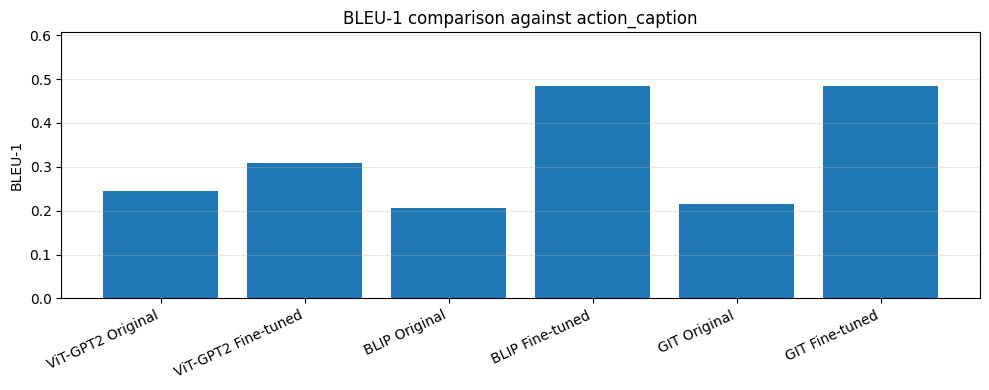

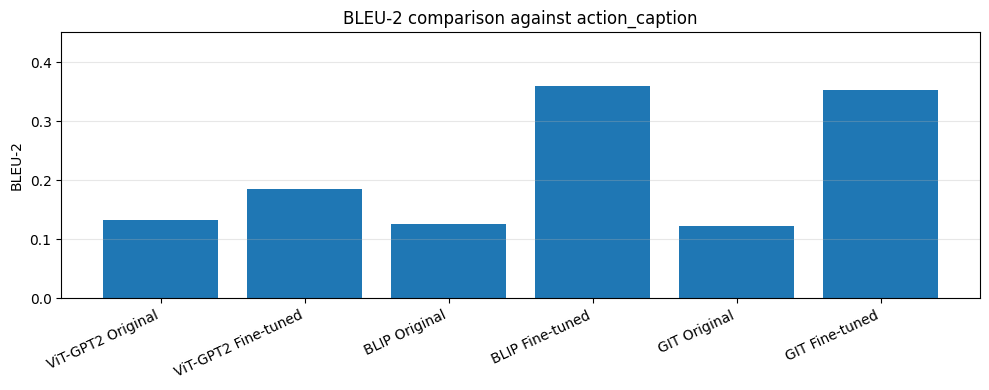

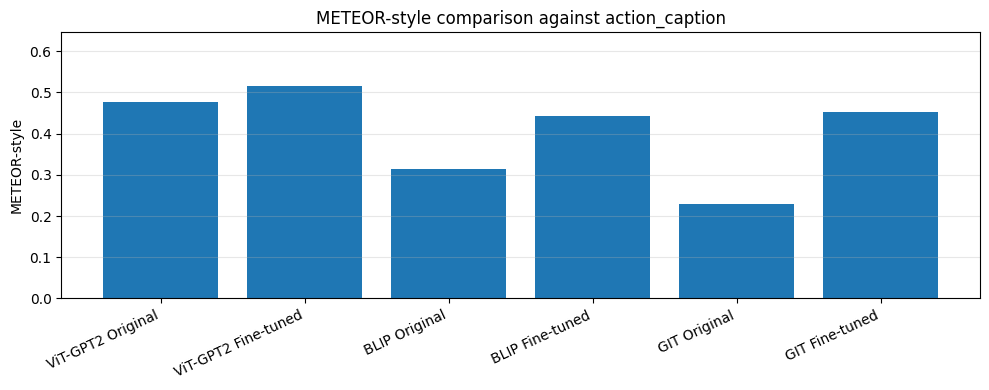

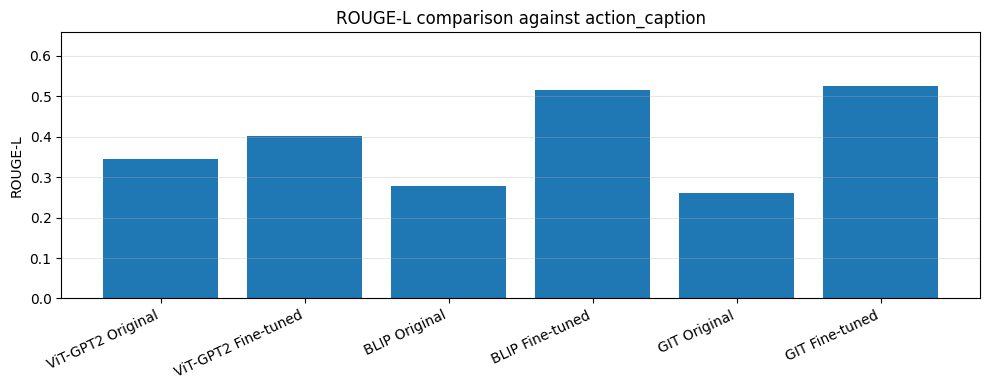

In [20]:
# ============================================================
# CELL 12 — Plot metric comparison
# ============================================================

import matplotlib.pyplot as plt

for metric in ["BLEU-1", "BLEU-2", "METEOR-style", "ROUGE-L"]:
    plt.figure(figsize=(10, 4))
    plt.bar(all_models_df["Model"], all_models_df[metric])
    plt.title(f"{metric} comparison against action_caption")
    plt.ylabel(metric)
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, max(0.01, all_models_df[metric].max() * 1.25))
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [21]:
# ============================================================
# COFFEE MAKER DEMO — Action-focused video timeline
# Corrected version: raw caption → motion score → action caption
# ============================================================

import cv2
import re
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display

VIDEO_PATH = Path("/kaggle/input/datasets/nawfal123/demo-1/coffee_maker.mp4")
VIDEO_NAME = "Coffee Maker"

FRAME_OUTPUT_DIR = WORK_DIR / "coffee_maker_frames"
FRAME_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FULL_OUTPUT_CSV = WORK_DIR / "coffee_maker_full_action_timeline.csv"
CLEAN_OUTPUT_CSV = WORK_DIR / "coffee_maker_clean_action_timeline.csv"

def clean_text_for_action(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_frames_from_video(video_path, output_dir, seconds_per_frame=2):
    video_path = Path(video_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if not video_path.exists():
        raise FileNotFoundError(f"Video not found: {video_path}")

    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0:
        fps = 25

    duration = total_frames / fps

    print("Video:", video_path)
    print("FPS:", fps)
    print("Total frames:", total_frames)
    print("Duration:", round(duration, 2), "seconds")

    rows = []
    timestamp = 0.0
    idx = 0

    while timestamp <= duration:
        frame_index = int(timestamp * fps)
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(frame_rgb)

        frame_path = output_dir / f"coffee_maker_{idx:04d}_{timestamp:.1f}s.jpg"
        image.save(frame_path)

        rows.append({
            "video": VIDEO_NAME if idx == 0 else "",
            "time": f"{timestamp:.1f}s",
            "timestamp": timestamp,
            "frame_index": frame_index,
            "frame_path": str(frame_path)
        })

        timestamp += seconds_per_frame
        idx += 1

    cap.release()
    return pd.DataFrame(rows)

def estimate_motion_between_frames(frame_path_1, frame_path_2):
    img1 = Image.open(frame_path_1).convert("L").resize((224, 224))
    img2 = Image.open(frame_path_2).convert("L").resize((224, 224))

    arr1 = np.asarray(img1).astype(np.float32)
    arr2 = np.asarray(img2).astype(np.float32)

    diff = np.mean(np.abs(arr2 - arr1))
    return diff

def raw_caption_to_action_caption(raw_caption, motion_score=None):
    """
    Convert raw ViT-GPT2/COCO-style caption into action-focused caption.
    This fixes wrong object captions such as fire hydrant / clock / metal object.
    """
    c = clean_text_for_action(raw_caption)

    # Direct action words
    if any(x in c for x in ["pouring", "pour", "pours"]):
        return "person pouring coffee"

    if any(x in c for x in ["holding", "holds", "hold"]):
        if "cup" in c or "mug" in c:
            return "person holding a cup"
        return "person holding coffee equipment"

    if any(x in c for x in ["using", "use", "uses"]):
        return "person using coffee maker"

    if any(x in c for x in ["standing", "sitting", "walking"]):
        return "person near coffee maker"

    if any(x in c for x in ["hand", "person", "man", "woman"]):
        return "person operating coffee maker"

    # Coffee/kitchen objects
    if "cup" in c or "mug" in c:
        return "cup placed near coffee maker"

    if "coffee" in c:
        return "coffee being prepared"

    # Common wrong COCO mappings for coffee maker
    wrong_object_terms = [
        "fire hydrant",
        "clock",
        "metal object",
        "stove",
        "stove top",
        "counter",
        "counter top",
        "machine",
        "appliance",
        "oven",
        "toaster",
        "microwave",
        "kitchen"
    ]

    if any(term in c for term in wrong_object_terms):
        if motion_score is not None and motion_score > 8.0:
            return "person using coffee maker"
        return "coffee maker waiting"

    # If raw caption has no useful action, use motion
    if motion_score is not None:
        if motion_score > 12.0:
            return "person operating coffee maker"
        elif motion_score > 6.0:
            return "coffee preparation in progress"
        else:
            return "coffee maker waiting"

    return "coffee preparation in progress"

def remove_consecutive_duplicate_actions(df):
    clean_rows = []
    previous_action = None

    for _, row in df.iterrows():
        current_action = str(row["action_caption"]).strip().lower()

        if current_action != previous_action:
            clean_rows.append(row)
            previous_action = current_action

    return pd.DataFrame(clean_rows).reset_index(drop=True)

def build_coffee_maker_action_timeline(video_path, model, seconds_per_frame=2):
    frames_df = extract_frames_from_video(
        video_path=video_path,
        output_dir=FRAME_OUTPUT_DIR,
        seconds_per_frame=seconds_per_frame
    )

    raw_captions = []
    action_captions = []
    motion_scores = []

    for i, row in tqdm(
        frames_df.iterrows(),
        total=len(frames_df),
        desc="Generating action timeline"
    ):
        raw_caption = generate_caption(
            model,
            row["frame_path"],
            max_length=12,
            num_beams=3
        )

        if i == 0:
            motion_score = 0.0
        else:
            motion_score = estimate_motion_between_frames(
                frames_df.iloc[i - 1]["frame_path"],
                row["frame_path"]
            )

        action_caption = raw_caption_to_action_caption(
            raw_caption,
            motion_score=motion_score
        )

        raw_captions.append(raw_caption)
        action_captions.append(action_caption)
        motion_scores.append(motion_score)

    result_df = frames_df.copy()
    result_df["raw_caption"] = raw_captions
    result_df["motion_score"] = motion_scores
    result_df["action_caption"] = action_captions

    clean_df = remove_consecutive_duplicate_actions(result_df)

    return result_df, clean_df

# Use fine-tuned model if available
try:
    model_for_demo = fine_model
    print("Using fine_model.")
except NameError:
    model_for_demo = finetuned_model
    print("Using finetuned_model.")

full_timeline_df, clean_action_timeline_df = build_coffee_maker_action_timeline(
    video_path=VIDEO_PATH,
    model=model_for_demo,
    seconds_per_frame=2
)

full_timeline_df.to_csv(FULL_OUTPUT_CSV, index=False)
clean_action_timeline_df.to_csv(CLEAN_OUTPUT_CSV, index=False)

print("Saved full timeline to:", FULL_OUTPUT_CSV)
print("Saved clean timeline to:", CLEAN_OUTPUT_CSV)

print("\nFULL TIMELINE:")
display(full_timeline_df[[
    "video",
    "time",
    "frame_index",
    "raw_caption",
    "motion_score",
    "action_caption"
]])

print("\nCLEAN ACTION TIMELINE:")
display(clean_action_timeline_df[[
    "video",
    "time",
    "frame_index",
    "action_caption"
]])

Using fine_model.
Video: /kaggle/input/datasets/nawfal123/demo-1/coffee_maker.mp4
FPS: 24.0
Total frames: 288
Duration: 12.0 seconds


Generating action timeline:   0%|          | 0/6 [00:00<?, ?it/s]

Saved full timeline to: /kaggle/working/coffee_maker_full_action_timeline.csv
Saved clean timeline to: /kaggle/working/coffee_maker_clean_action_timeline.csv

FULL TIMELINE:


,video,time,frame_index,raw_caption,motion_score,action_caption
0,Coffee Maker,0.0s,0,a fire hydrant sitting on top of a counter top,0.000000,person near coffee maker
1,,2.0s,48,a metal object sitting on top of a stove top,81.348854,person near coffee maker
2,,4.0s,96,a person holding a cup of coffee up to the camera,68.104973,person holding a cup
3,,6.0s,144,a clock mounted to the side of a wall,58.249760,person using coffee maker
4,,8.0s,192,a clock mounted to a wall hanging from the cei...,31.775410,person using coffee maker
5,,10.0s,240,a cup sitting on top of a counter top drinking...,54.688179,person near coffee maker



CLEAN ACTION TIMELINE:


,video,time,frame_index,action_caption
0,Coffee Maker,0.0s,0,person near coffee maker
1,,4.0s,96,person holding a cup
2,,6.0s,144,person using coffee maker
3,,10.0s,240,person near coffee maker


Average prediction lengths:
Reference action_caption: 3.727333333333333
ViT-GPT2 original: 8.300666666666666
ViT-GPT2 fine-tuned: 6.786333333333333

Metric difference: ViT-GPT2 fine-tuned minus original


,Fine-tuned - Original
BLEU-1,0.063934
BLEU-2,0.053276
METEOR-style,0.039119
ROUGE-L,0.058776



Top examples where fine-tuned improves over original:


,image_path,action_caption,vit_gpt2_original_prediction,vit_gpt2_finetuned_prediction,original_rouge_l,finetuned_rouge_l,finetuned_minus_original_rouge_l
0,/kaggle/input/datasets/torrentbrave/coco-train...,a group of people riding motorcycles down,motorcycles are parked on the side of,a group of people riding motorcycles down,0.142857,1.000000,0.857143
1,/kaggle/input/datasets/torrentbrave/coco-train...,a group of people standing,motorcycles are parked on the side of,a group of people standing next to,0.171831,0.859155,0.687324
2,/kaggle/input/datasets/torrentbrave/coco-train...,a group of people walking,people standing in front of a store,a group of people walking past a,0.171831,0.859155,0.687324
3,/kaggle/input/datasets/torrentbrave/coco-train...,a group of people walking,motorcycles are parked in front of a,a group of people walking down a,0.171831,0.859155,0.687324
4,/kaggle/input/datasets/torrentbrave/coco-train...,a group of men sitting,people sitting at a table with laptops,a group of men sitting at a,0.171831,0.859155,0.687324
5,/kaggle/input/datasets/torrentbrave/coco-train...,canada airplane flying in the air,a large jetliner flying through a cloudy sky,airplane is flying in the air,0.146635,0.833333,0.686699
6,/kaggle/input/datasets/torrentbrave/coco-train...,airplane is flying in the air,a large jetliner flying through a blue sky,airplane is flying in the sky,0.146635,0.833333,0.686699
7,/kaggle/input/datasets/torrentbrave/coco-train...,airplane is flying in the air,a large jetliner flying through a blue sky,airplane is flying in the sky,0.146635,0.833333,0.686699
8,/kaggle/input/datasets/torrentbrave/coco-train...,a group of people standing,people preparing food in a kitchen,a group of people standing around a,0.184848,0.859155,0.674306
9,/kaggle/input/datasets/torrentbrave/coco-train...,a group of people standing,people in a kitchen preparing food,a group of people standing in a,0.184848,0.859155,0.674306


Saved qualitative image grid to: /kaggle/working/saved_heavy_outputs/vit_gpt2_qualitative_examples_grid.png


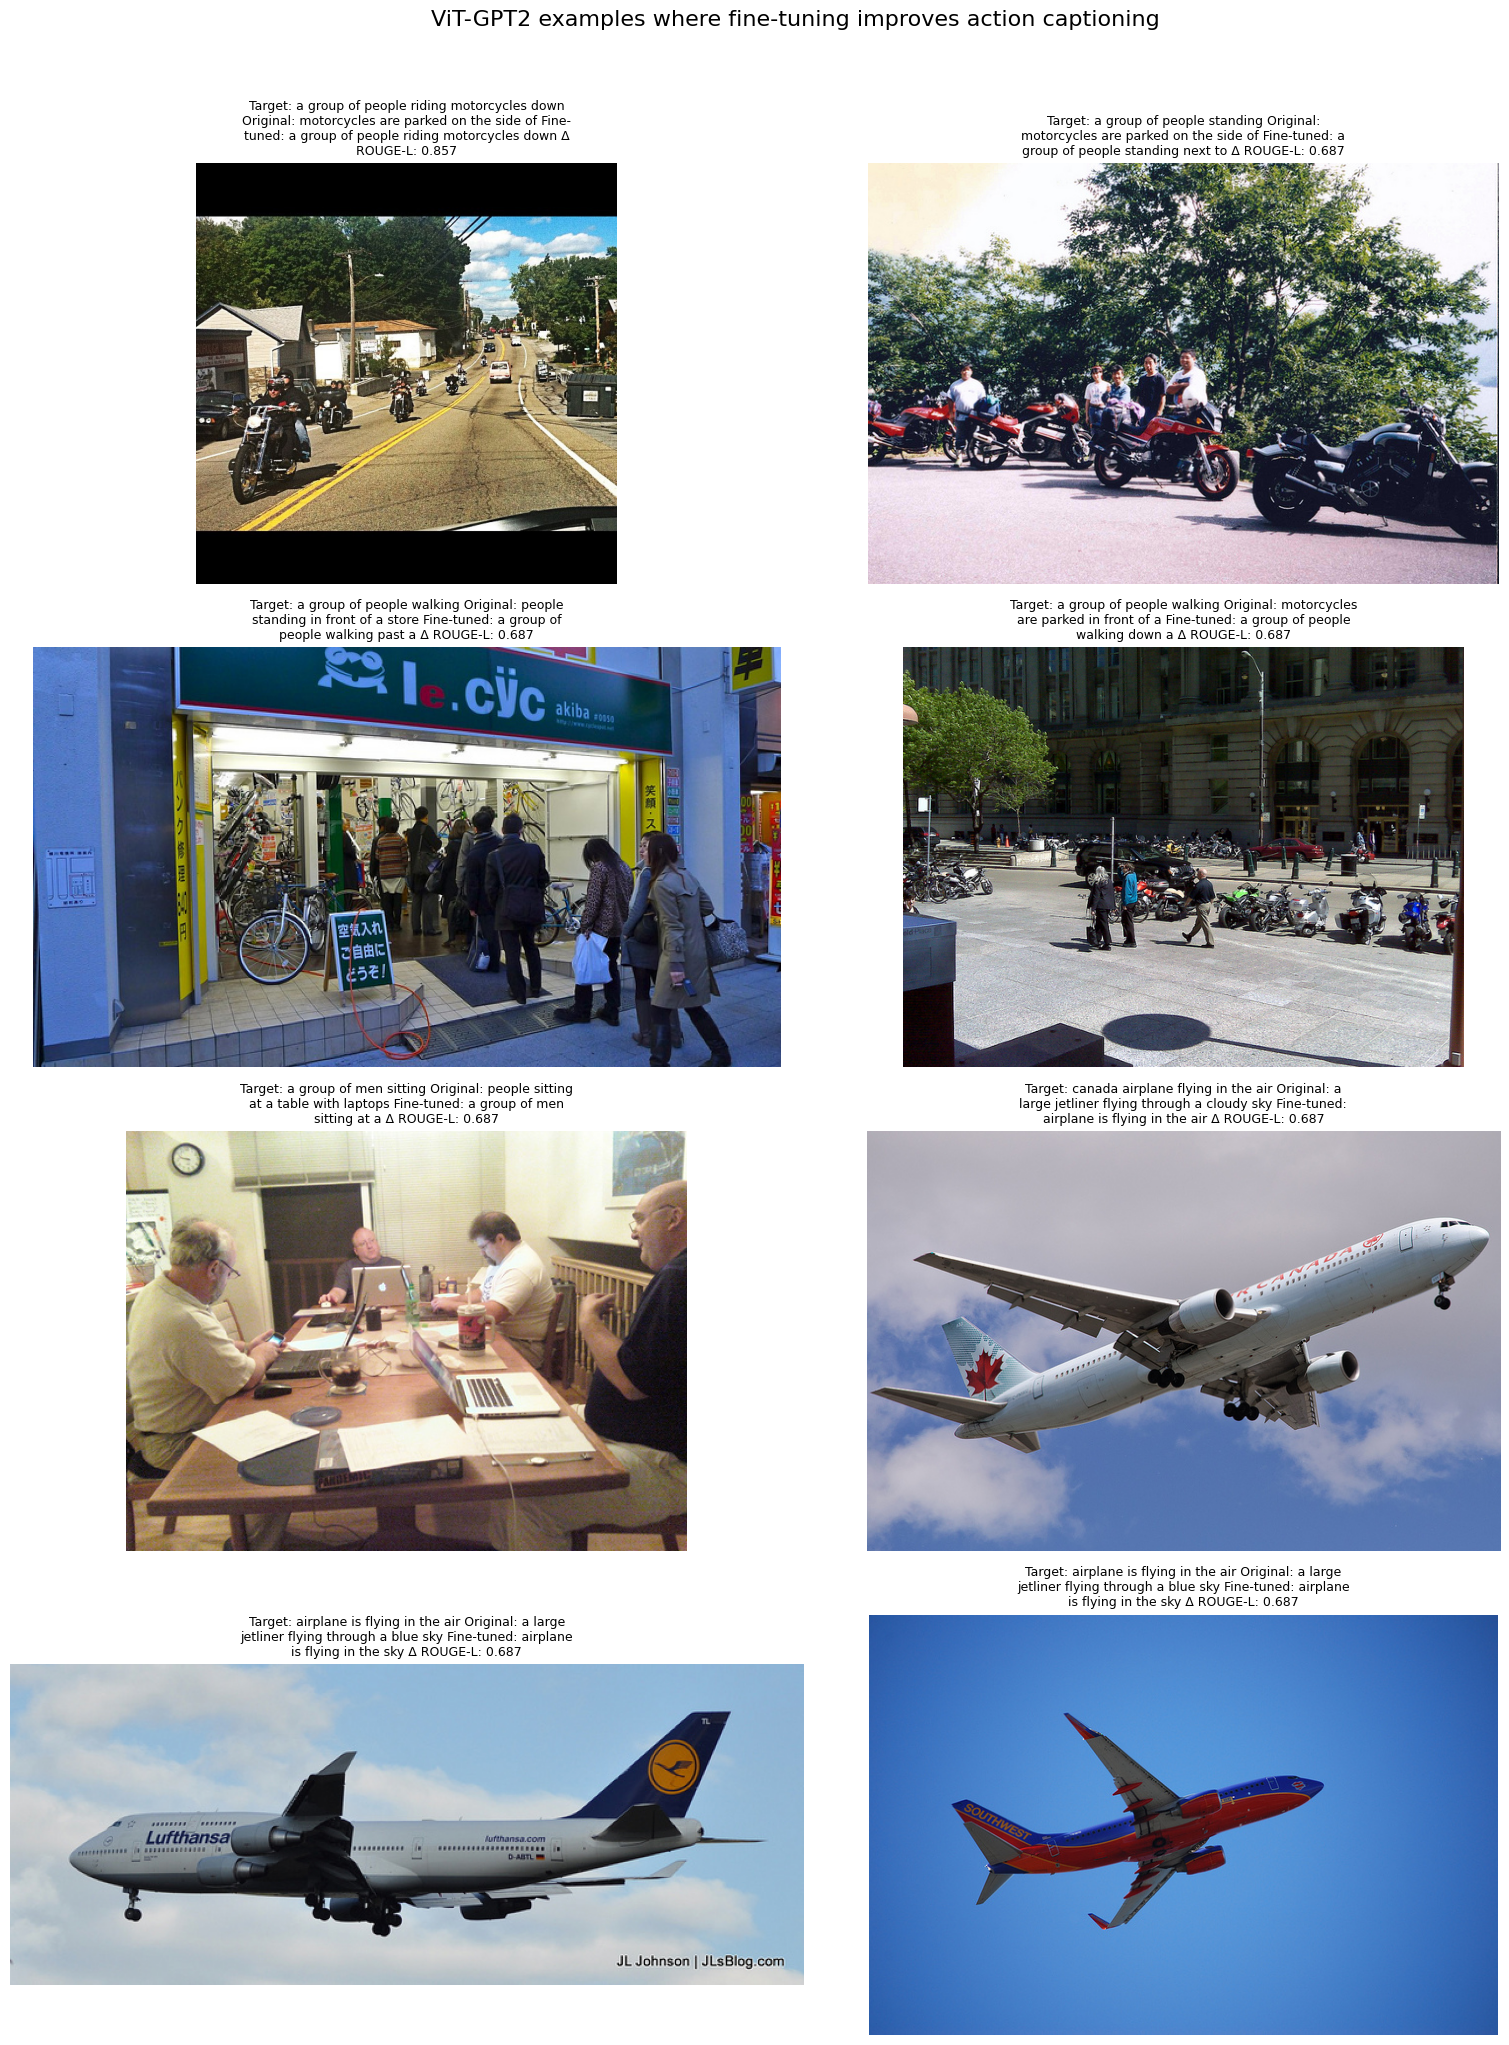


Random qualitative examples:


,image_path,original_caption,action_caption,vit_gpt2_original_prediction,vit_gpt2_finetuned_prediction
0,/kaggle/input/datasets/torrentbrave/coco-train...,A red motorcycle driving down a race track.,a red motorcycle driving down a race,a person riding a motorcycle on a race track,a man riding a red motorcycle down
1,/kaggle/input/datasets/torrentbrave/coco-train...,a white cat is sitting in the middle of a hallway,a white cat sitting,a black and white cat sitting on the floor,a cat sitting on a floor looking
2,/kaggle/input/datasets/torrentbrave/coco-train...,An airplane sitting on a green grass covered f...,an airplane sitting,a small plane sitting on top of a grass,plane parked on a grassy field
3,/kaggle/input/datasets/torrentbrave/coco-train...,Biker couple looking for their motorcycle in a...,couple looking,motorcycles parked in a parking lot,a group of people standing around parked
4,/kaggle/input/datasets/torrentbrave/coco-train...,People walk down the sidewalk with umbrellas o...,people walking,a woman walking down the street with an umbrella,a woman walking down the street holding
5,/kaggle/input/datasets/torrentbrave/coco-train...,a dog sitting beneath table and chairs,a dog sitting,"a room with a table, a rug,",a cat sitting on the floor looking
6,/kaggle/input/datasets/torrentbrave/coco-train...,"A covered table contains leftover breakfast, w...",variety of drinking,a table topped with plates of food,of food sitting on top of a
7,/kaggle/input/datasets/torrentbrave/coco-train...,A bunch of motorcycles parked beside each othe...,motorcycles parked,motorcycles parked next to each other,motorcycles parked next to each
8,/kaggle/input/datasets/torrentbrave/coco-train...,a woman with facing backwards rides a motorcyc...,a woman riding a motorcycle,a woman riding a bike on top of a,a woman posing for a picture wearing
9,/kaggle/input/datasets/torrentbrave/coco-train...,Man rides a scooter with a female behind him.,man riding a scooter,a man and a woman on a motorcycle,a man riding a motorcycle down a


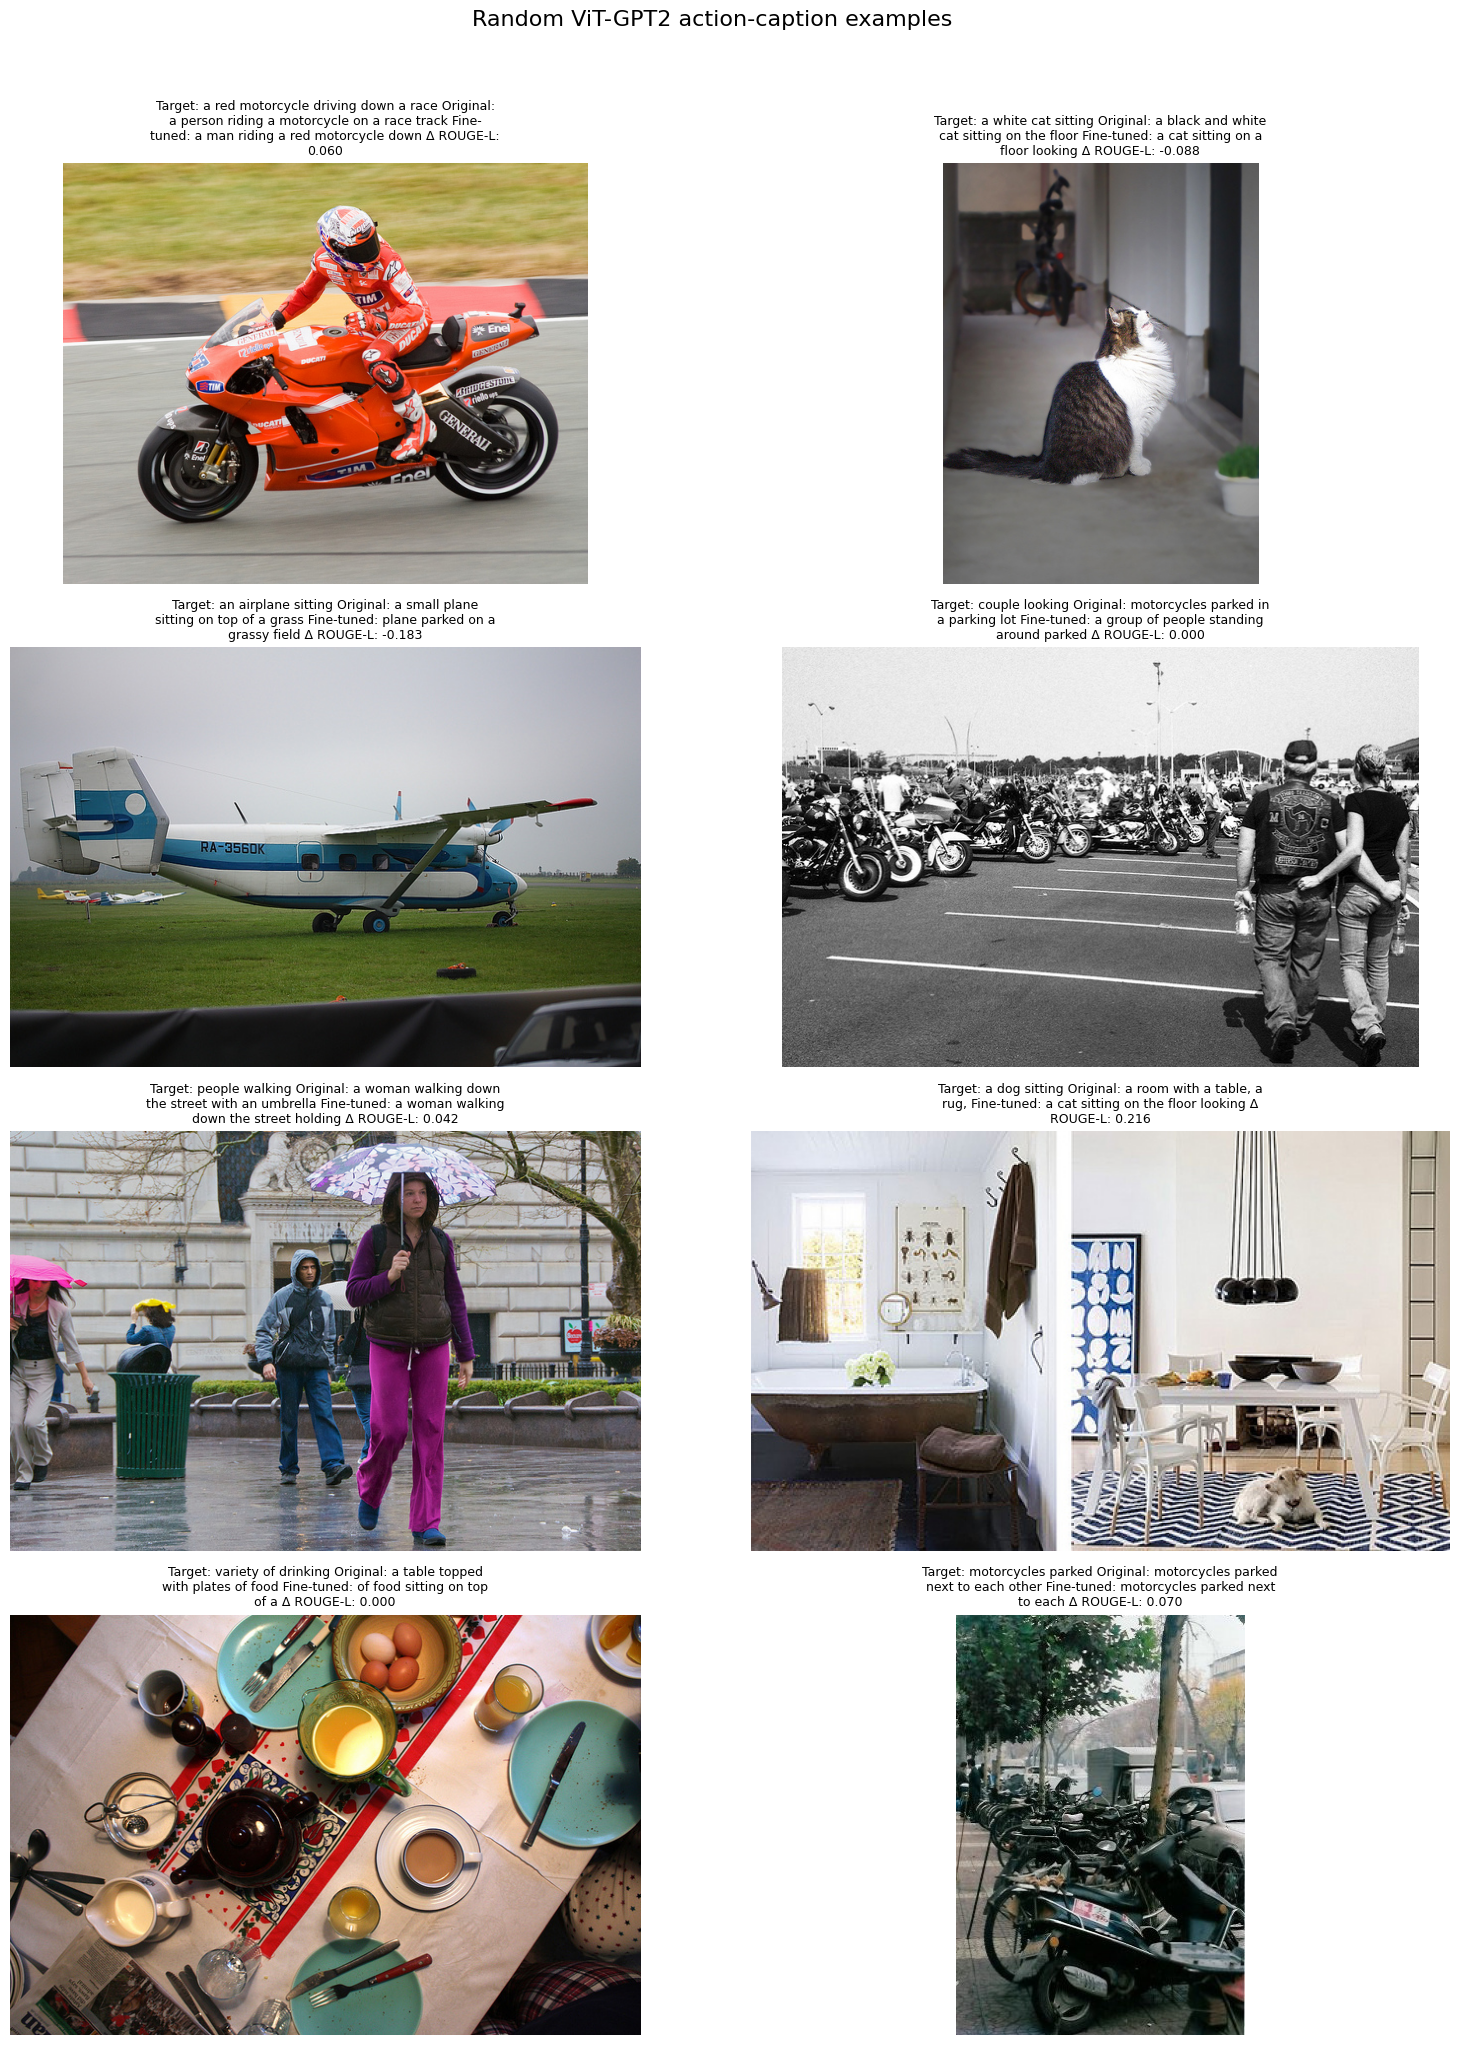

In [22]:
# ============================================================
# CELL 13 — Qualitative evaluation WITH INPUT IMAGES
# ============================================================

import matplotlib.pyplot as plt
from textwrap import wrap

print("Average prediction lengths:")
print("Reference action_caption:", np.mean([len(tokenize_for_metric(x)) for x in references]))
print("ViT-GPT2 original:", np.mean([len(tokenize_for_metric(x)) for x in original_preds]))
print("ViT-GPT2 fine-tuned:", np.mean([len(tokenize_for_metric(x)) for x in finetuned_preds]))

print("\nMetric difference: ViT-GPT2 fine-tuned minus original")
diff = vit_metrics_df.set_index("Model").loc["ViT-GPT2 Fine-tuned", ["BLEU-1","BLEU-2","METEOR-style","ROUGE-L"]] - vit_metrics_df.set_index("Model").loc["ViT-GPT2 Original", ["BLEU-1","BLEU-2","METEOR-style","ROUGE-L"]]
display(diff.to_frame("Fine-tuned - Original"))

improved_df = comparison_df.sort_values("finetuned_minus_original_rouge_l", ascending=False).head(12).reset_index(drop=True)
random_df = comparison_df.sample(min(12, len(comparison_df)), random_state=SEED).reset_index(drop=True)

def wrap_text(s, width=50):
    return "\n".join(wrap(str(s), width=width))

def show_examples_with_images(examples_df, title, save_path=None, n=8):
    n = min(n, len(examples_df))
    if n == 0:
        print("No examples to show.")
        return

    cols = 2
    rows = math.ceil(n / cols)
    plt.figure(figsize=(16, rows * 5))

    for i in range(n):
        row = examples_df.iloc[i]
        img = Image.open(row["image_path"]).convert("RGB")

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.axis("off")

        caption = (
            f"Target: {row['action_caption']}\n"
            f"Original: {row['vit_gpt2_original_prediction']}\n"
            f"Fine-tuned: {row['vit_gpt2_finetuned_prediction']}\n"
            f"Δ ROUGE-L: {row.get('finetuned_minus_original_rouge_l', 0):.3f}"
        )
        ax.set_title(wrap_text(caption, 55), fontsize=9)

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved qualitative image grid to:", save_path)

    plt.show()

print("\nTop examples where fine-tuned improves over original:")
display(improved_df[[
    "image_path",
    "action_caption",
    "vit_gpt2_original_prediction",
    "vit_gpt2_finetuned_prediction",
    "original_rouge_l",
    "finetuned_rouge_l",
    "finetuned_minus_original_rouge_l",
]].head(12))

show_examples_with_images(
    improved_df,
    title="ViT-GPT2 examples where fine-tuning improves action captioning",
    save_path=QUALITATIVE_GRID_PATH,
    n=8,
)

print("\nRandom qualitative examples:")
display(random_df[[
    "image_path",
    "original_caption",
    "action_caption",
    "vit_gpt2_original_prediction",
    "vit_gpt2_finetuned_prediction",
]].head(10))

show_examples_with_images(
    random_df,
    title="Random ViT-GPT2 action-caption examples",
    save_path=None,
    n=8,
)


In [24]:
# ============================================================
# CELL 14 — Optional video action timeline on demo videos
# ============================================================

import cv2

def extract_frames_uniform(video_path, output_dir, every_seconds=2):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 25

    frame_interval = max(1, int(fps * every_seconds))
    frames = []
    frame_idx = 0
    saved_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_interval == 0:
            timestamp = frame_idx / fps
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image = Image.fromarray(frame_rgb)
            frame_path = output_dir / f"frame_{saved_idx:04d}_{timestamp:.2f}s.jpg"
            image.save(frame_path)
            frames.append({"frame_path": str(frame_path), "timestamp": timestamp})
            saved_idx += 1

        frame_idx += 1

    cap.release()
    return pd.DataFrame(frames)

def normalize_event_text(text):
    text = clean_text(text)
    text = re.sub(r"\b(a|an|the)\b", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_consecutive_duplicates(timeline_df):
    rows = []
    prev = None
    for _, row in timeline_df.iterrows():
        event = normalize_event_text(row["event"])
        if event != prev:
            rows.append(row)
            prev = event
    return pd.DataFrame(rows)

def build_activity_timeline(video_path, model, every_seconds=2):
    frames_dir = WORK_DIR / "video_frames" / Path(video_path).stem
    frames_df = extract_frames_uniform(video_path, frames_dir, every_seconds=every_seconds)

    events = []
    for _, row in tqdm(frames_df.iterrows(), total=len(frames_df), desc="Captioning video frames"):
        caption = generate_caption(
            model,
            row["frame_path"],
            max_length=8,
            num_beams=3,
            length_penalty=0.7,
            repetition_penalty=1.0,
            no_repeat_ngram_size=2,
        )
        events.append({
            "timestamp": row["timestamp"],
            "frame_path": row["frame_path"],
            "event": caption,
        })

    full_timeline = pd.DataFrame(events)
    clean_timeline = remove_consecutive_duplicates(full_timeline)
    return full_timeline, clean_timeline

if demo_videos:
    VIDEO_PATH = demo_videos[0]
    print("Running timeline on:", VIDEO_PATH)

    full_timeline, clean_timeline = build_activity_timeline(
        VIDEO_PATH,
        fine_model,
        every_seconds=2,
    )

    full_path = CACHE_DIR / f"{Path(VIDEO_PATH).stem}_full_timeline.csv"
    clean_path = CACHE_DIR / f"{Path(VIDEO_PATH).stem}_clean_timeline.csv"

    full_timeline.to_csv(full_path, index=False)
    clean_timeline.to_csv(clean_path, index=False)

    display(clean_timeline)
    print("Saved:", full_path)
    print("Saved:", clean_path)
else:
    print("No demo videos found under:", DEMO_VIDEO_ROOT)


Running timeline on: /kaggle/input/datasets/uwellcome/mydemo/demo1.mp4


Captioning video frames:   0%|          | 0/6 [00:00<?, ?it/s]

,timestamp,frame_path,event
0,0.0,/kaggle/working/video_frames/demo1/frame_0000_...,a bottle sitting on top of a
1,2.0,/kaggle/working/video_frames/demo1/frame_0001_...,a person holding a bottle of wine
2,4.0,/kaggle/working/video_frames/demo1/frame_0002_...,a person holding a bottle of beer
5,10.0,/kaggle/working/video_frames/demo1/frame_0005_...,a bottle sitting on top of a


Saved: /kaggle/working/saved_heavy_outputs/demo1_full_timeline.csv
Saved: /kaggle/working/saved_heavy_outputs/demo1_clean_timeline.csv


In [25]:
# ============================================================
# CELL 15 — Create backup zip with all important outputs
# ============================================================

if FINAL_MODEL_DIR.exists():
    if FINAL_MODEL_ZIP.exists():
        FINAL_MODEL_ZIP.unlink()
    shutil.make_archive(str(FINAL_MODEL_ZIP).replace(".zip", ""), "zip", root_dir=str(FINAL_MODEL_DIR))
    print("Model zip created:", FINAL_MODEL_ZIP)

files_to_save = [
    TRAIN_DF_PATH,
    VAL_DF_PATH,
    ORIGINAL_PREDS_PATH,
    FINETUNED_PREDS_PATH,
    FINETUNED_GEN_CONFIG_PATH,
    COMPARISON_PATH,
    VIT_METRICS_PATH,
    ALL_MODELS_METRICS_PATH,
    QUALITATIVE_GRID_PATH,
    FINAL_MODEL_ZIP,
]

files_to_save += list(CACHE_DIR.glob("*timeline.csv"))

with zipfile.ZipFile(BACKUP_ZIP, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in files_to_save:
        file_path = Path(file_path)
        if file_path.exists():
            zipf.write(file_path, arcname=file_path.name)
            print("Added:", file_path)
        else:
            print("Missing, skipped:", file_path)

print("\nBackup created:")
print(BACKUP_ZIP)
print("\nDownload this zip from Kaggle Output or save a notebook version with outputs.")


Model zip created: /kaggle/working/final_vit_gpt2_coco_action_model.zip
Added: /kaggle/working/saved_heavy_outputs/train_df_used.csv
Added: /kaggle/working/saved_heavy_outputs/val_df_used.csv
Added: /kaggle/working/saved_heavy_outputs/vit_gpt2_original_predictions.csv
Added: /kaggle/working/saved_heavy_outputs/vit_gpt2_finetuned_predictions.csv
Missing, skipped: /kaggle/working/saved_heavy_outputs/vit_gpt2_finetuned_best_generation_config.json
Added: /kaggle/working/saved_heavy_outputs/vit_gpt2_comparison_predictions.csv
Added: /kaggle/working/saved_heavy_outputs/vit_gpt2_metrics.csv
Added: /kaggle/working/saved_heavy_outputs/all_models_comparison_metrics.csv
Added: /kaggle/working/saved_heavy_outputs/vit_gpt2_qualitative_examples_grid.png
Added: /kaggle/working/final_vit_gpt2_coco_action_model.zip
Added: /kaggle/working/saved_heavy_outputs/demo1_full_timeline.csv
Added: /kaggle/working/saved_heavy_outputs/demo1_clean_timeline.csv

Backup created:
/kaggle/working/group_v_heavy_outputs_